In [14]:
import pandas as pd
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


In [2]:
print("Number of rows in dataset:", len(df))
print("Number of North Atlantic datapoints:", (df["BASIN"] == "NA").sum())

Number of rows in dataset: 716165
Number of North Atlantic datapoints: 126392


## 1) Get the unique values of the BASIN, SUBBASIN, and NATURE columns

In [15]:
print("BASIN unique values:")
print(df["BASIN"].unique())

print("\nSUBBASIN unique values:")
print(df["SUBBASIN"].unique())

print("\nNATURE unique values:")
print(df["NATURE"].unique())

BASIN unique values:
['NI' 'SI' 'NA' 'EP' 'WP' 'SP' 'SA']

SUBBASIN unique values:
['BB' 'AS' 'MM' 'GM' 'NA' 'CS' 'WA' 'EA' 'CP']

NATURE unique values:
['NR' 'TS' 'ET' 'SS' 'MX' 'DS']


## 2) Rename the WMO_WIND and WMO_PRES columns to WIND and PRES

In [16]:
df = df.rename(columns={"WMO_WIND": "WIND", "WMO_PRES": "PRES"})
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9000,80.3000,NaN,NaN
1,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 06:00:00,NR,10.8709,79.8265,NaN,NaN
2,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 09:00:00,NR,10.8431,79.3524,NaN,NaN
3,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 12:00:00,NR,10.8188,78.8772,NaN,NaN
4,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 15:00:00,NR,10.8000,78.4000,NaN,NaN


## 3) Get the 10 largest rows in the dataset by WIND

In [17]:
top10_rows = df.nlargest(10, "WIND")
top10_rows

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


## 4) Group the data on SID and get the 10 largest hurricanes by WIND

In [18]:
top10_hurricanes = (
    df.groupby("SID")[["WIND"]]
      .max()
      .sort_values("WIND", ascending=False)
      .head(10)
)

top10_hurricanes

,WIND
SID,
2015293N13266,185.0
1980214N11330,165.0
2019236N10314,160.0
1988253N12306,160.0
2005289N18282,160.0
1935241N23291,160.0
1997253N12255,160.0
2009288N07267,155.0
1998295N12284,155.0


## 5) Make a bar chart of the wind speed of the 20 strongest-wind hurricanes

<Figure size 1200x600 with 0 Axes>

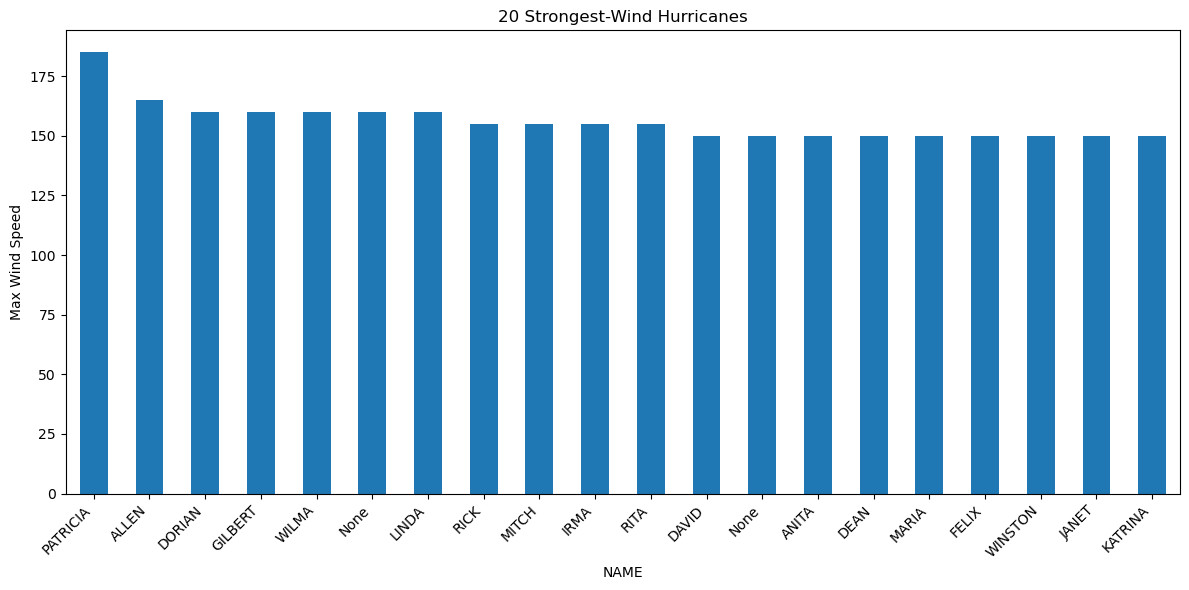

In [19]:
import matplotlib.pyplot as plt
import numpy as np

top20_hurricanes = (
    df.groupby("SID")
      .agg({"NAME": "first", "WIND": "max"})
      .sort_values("WIND", ascending=False)
      .head(20)
)

plt.figure(figsize=(12, 6))
top20_hurricanes.plot(
    kind="bar",
    x="NAME",
    y="WIND",
    legend=False,
    figsize=(12, 6)
)
plt.ylabel("Max Wind Speed")
plt.title("20 Strongest-Wind Hurricanes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6) Plot the count of all datapoints by Basin

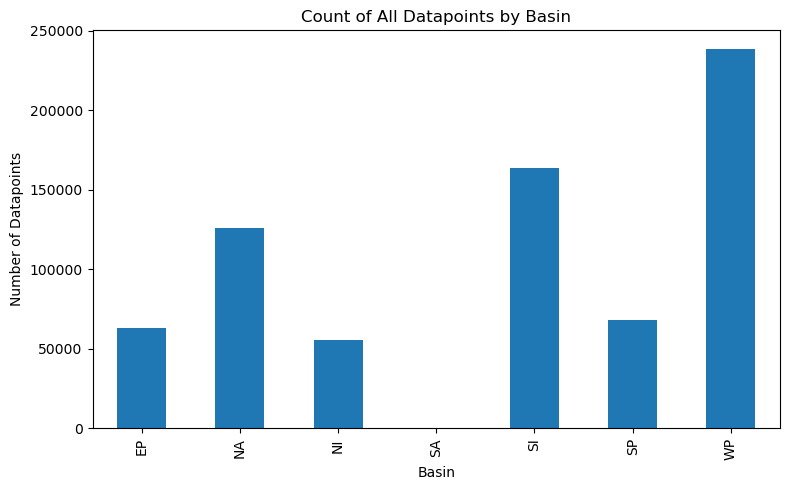

In [20]:
basin_counts = df["BASIN"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
basin_counts.plot(kind="bar")
plt.xlabel("Basin")
plt.ylabel("Number of Datapoints")
plt.title("Count of All Datapoints by Basin")
plt.tight_layout()
plt.show()

## 7) Plot the count of unique hurricanes by Basin

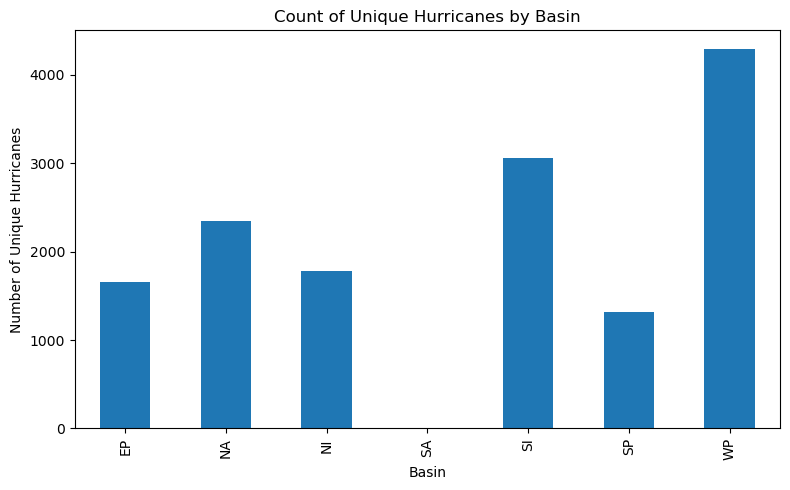

In [21]:
unique_hurricanes_by_basin = df.groupby("BASIN")["SID"].nunique().sort_index()

plt.figure(figsize=(8, 5))
unique_hurricanes_by_basin.plot(kind="bar")
plt.xlabel("Basin")
plt.ylabel("Number of Unique Hurricanes")
plt.title("Count of Unique Hurricanes by Basin")
plt.tight_layout()
plt.show()

## 8) Make a hexbin of the location of datapoints in Latitude and Longitude

<Figure size 1000x600 with 0 Axes>

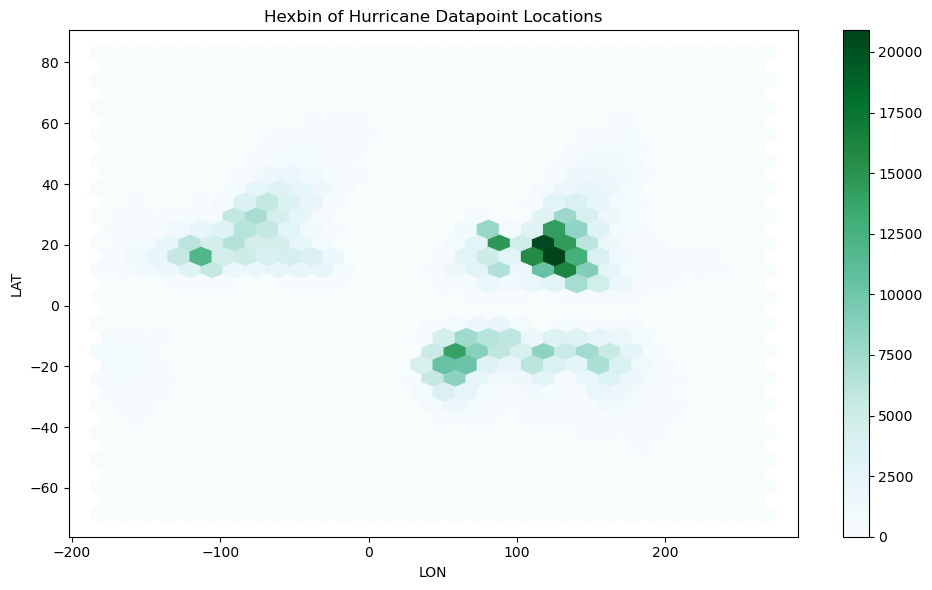

In [22]:
plt.figure(figsize=(10, 6))
df.plot.hexbin(
    x="LON",
    y="LAT",
    gridsize=30,
    figsize=(10, 6)
)
plt.title("Hexbin of Hurricane Datapoint Locations")
plt.tight_layout()
plt.show()

## 9) Find Hurricane Katrina (from 2005) and plot its track as a scatter plot

In [23]:
katrina = df[(df["NAME"] == "KATRINA") & (df["SEASON"] == 2005)]
katrina[["SID", "NAME", "SEASON", "ISO_TIME", "LAT", "LON", "WIND"]].head()

,SID,NAME,SEASON,ISO_TIME,LAT,LON,WIND
603763,2005236N23285,KATRINA,2005,2005-08-23 18:00:00,23.1000,-75.1000,30.0
603764,2005236N23285,KATRINA,2005,2005-08-23 21:00:00,23.2476,-75.4049,NaN
603765,2005236N23285,KATRINA,2005,2005-08-24 00:00:00,23.4000,-75.7000,30.0
603766,2005236N23285,KATRINA,2005,2005-08-24 03:00:00,23.5700,-75.9726,NaN
603767,2005236N23285,KATRINA,2005,2005-08-24 06:00:00,23.8000,-76.2000,30.0


In [24]:
katrina_sid = katrina["SID"].iloc[0]
print("Katrina SID:", katrina_sid)

Katrina SID: 2005236N23285


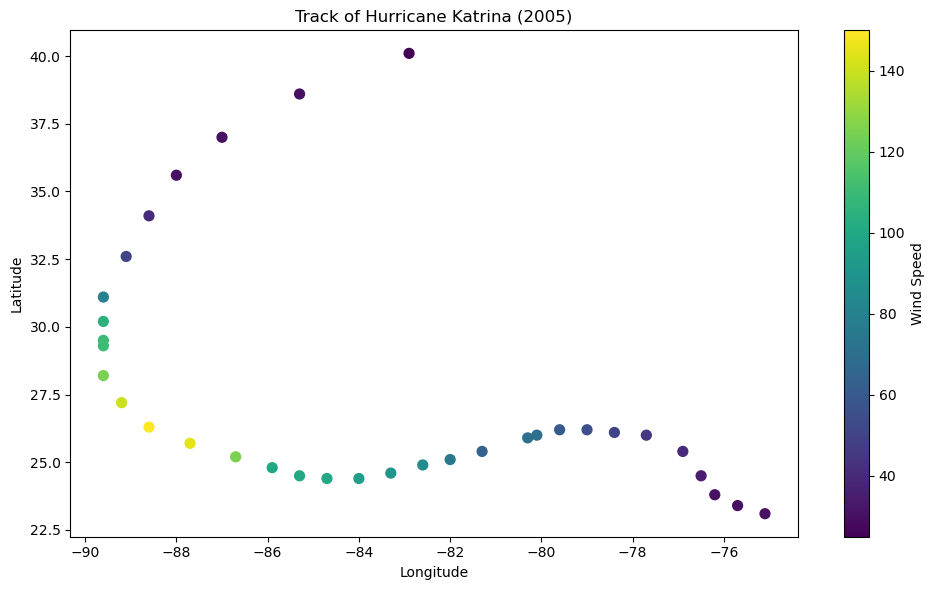

In [25]:
katrina_track = df[df["SID"] == katrina_sid]

plt.figure(figsize=(10, 6))
plt.scatter(
    katrina_track["LON"],
    katrina_track["LAT"],
    c=katrina_track["WIND"],
    s=50
)
plt.colorbar(label="Wind Speed")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Track of Hurricane Katrina (2005)")
plt.tight_layout()
plt.show()

## 10) Make time the index on your dataframe

In [26]:
df = df.set_index("ISO_TIME")
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.9000,80.3000,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8709,79.8265,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8431,79.3524,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8188,78.8772,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8000,78.4000,NaN,NaN


## 11) Count of all datapoints per year as a timeseries

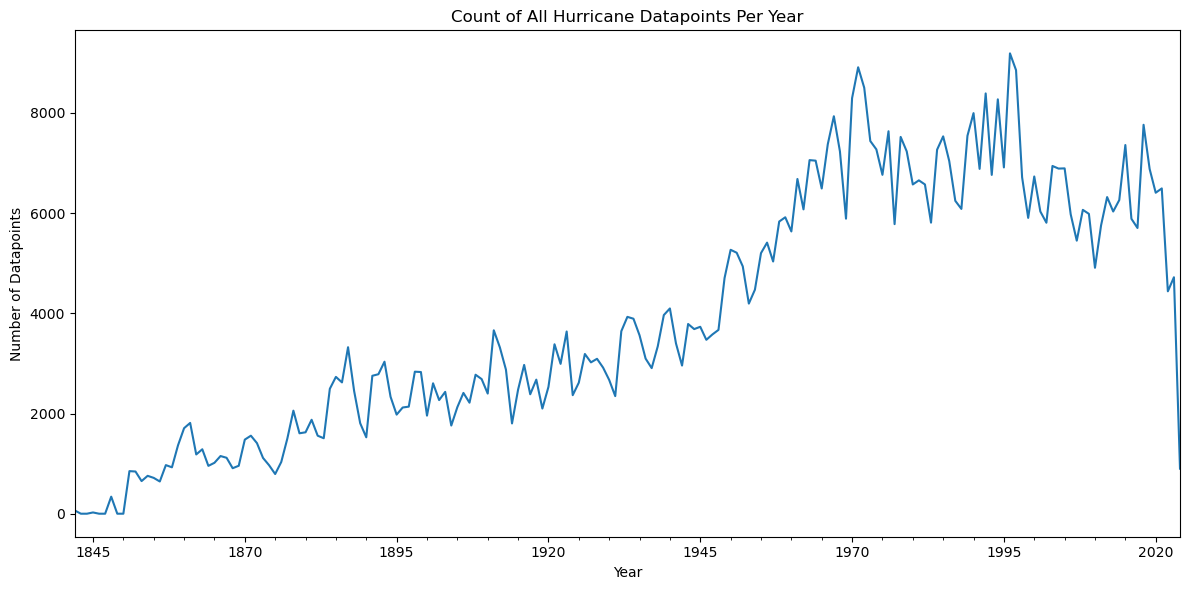

ISO_TIME
1842    65
1843     0
1844     0
1845    25
1846     0
Name: SID, dtype: int64

In [30]:
datapoints_per_year = df["SID"].resample("YE").count()

plt.figure(figsize=(12, 6))
datapoints_per_year.plot()
plt.xlabel("Year")
plt.ylabel("Number of Datapoints")
plt.title("Count of All Hurricane Datapoints Per Year")
plt.tight_layout()
plt.show()

datapoints_per_year.index = datapoints_per_year.index.year
datapoints_per_year.head()